<a href="https://colab.research.google.com/github/adi-asu-git/FSE570-Alaska/blob/main/capstone_phase1_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
path = "/content/drive/MyDrive/Capstone/final_merge.csv"

df = pd.read_csv(path)

In [ ]:
df.shape

(3076, 46)

In [ ]:
df.columns

Index(['county', 'state', 'ruca', 'brfss_access2_ageadjprv',
       'brfss_checkup_ageadjprv', 'brfss_csmoking_ageadjprv',
       'brfss_depression_ageadjprv', 'brfss_diabetes_ageadjprv',
       'brfss_ghlth_ageadjprv', 'brfss_mhlth_ageadjprv',
       'brfss_obesity_ageadjprv', 'pct_ed_lt9', 'pct_ed_9_12', 'pct_ed_hs',
       'pct_ed_sc', 'pct_ed_asc', 'pct_ed_b', 'pct_ed_gr', 'pct_age_gte65',
       'pct_race_white', 'pct_race_black', 'pct_race_aian', 'pct_race_asian',
       'pct_race_nhopi', 'pct_race_other', 'pct_eth_hisp', 'pct_sex_male',
       'pct_sex_female', 'pct_occ_unemp', 'pct_occ_mgt', 'pct_occ_svc',
       'pct_occ_sales', 'pct_occ_nat_res', 'pct_occ_prod', 'pct_hlth_unins',
       'pct_ses_pov', 'pct_tp_veh_0', 'pct_tp_veh_1', 'pct_tp_veh_2',
       'pct_tp_veh_3', 'pct_dg_bb_int', 'bb_int_struct', 'ruca_metro',
       'ruca_micro', 'ruca_small_town', 'ruca_rural'],
      dtype='object')

In [ ]:
df.head()

,county,state,ruca,brfss_access2_ageadjprv,brfss_checkup_ageadjprv,brfss_csmoking_ageadjprv,brfss_depression_ageadjprv,brfss_diabetes_ageadjprv,brfss_ghlth_ageadjprv,brfss_mhlth_ageadjprv,...,pct_tp_veh_0,pct_tp_veh_1,pct_tp_veh_2,pct_tp_veh_3,pct_dg_bb_int,bb_int_struct,ruca_metro,ruca_micro,ruca_small_town,ruca_rural
0,Aleutians East,Alaska,10.0,16.9,60.7,18.6,13.1,12.6,19.1,12.9,...,24.0,37.2,28.0,10.8,57.5,0.0000,0,0,0,1
1,Aleutians West,Alaska,10.0,13.7,61.6,15.5,13.4,10.9,15.3,12.2,...,14.2,39.8,35.5,10.5,77.0,0.0000,0,0,0,1
2,Anchorage,Alaska,1.0,10.4,62.9,14.9,19.5,7.8,13.5,14.5,...,5.5,32.9,39.8,21.8,92.7,1.0000,1,0,0,0
3,Bethel,Alaska,9.0,19.2,62.6,35.4,21.2,15.9,30.0,21.4,...,60.1,23.9,11.6,4.4,74.8,0.0179,0,0,1,0
4,Bristol Bay,Alaska,10.0,10.3,61.4,18.7,18.8,8.6,14.4,15.4,...,9.8,39.4,24.8,26.0,76.5,0.0000,0,0,0,1


3076 counties
46 variables

In [ ]:
df["brfss_obesity_ageadjprv"].describe()

,brfss_obesity_ageadjprv
count,3076.000000
mean,37.418043
std,4.540905
min,17.400000
25%,35.200000
50%,37.700000
75%,40.300000
max,52.500000


In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
ruca,3
county,0
state,0
brfss_access2_ageadjprv,0
brfss_checkup_ageadjprv,0
brfss_csmoking_ageadjprv,0
brfss_depression_ageadjprv,0
brfss_diabetes_ageadjprv,0
brfss_ghlth_ageadjprv,0
brfss_mhlth_ageadjprv,0


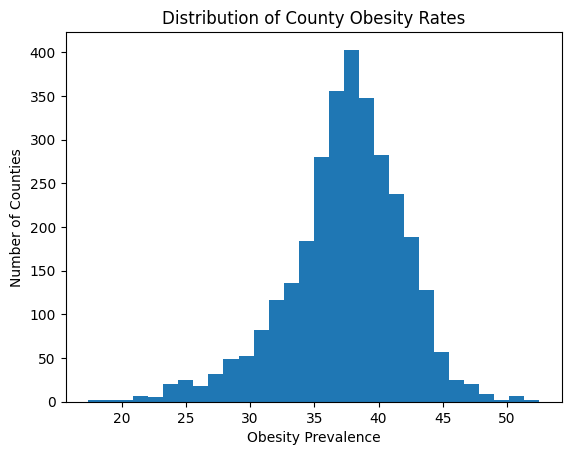

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df["brfss_obesity_ageadjprv"], bins=30)
plt.xlabel("Obesity Prevalence")
plt.ylabel("Number of Counties")
plt.title("Distribution of County Obesity Rates")
plt.show()

• 3076 counties → correct size (US counties ≈ 3100)
• No missing values except ruca (3 rows) → negligible
• Obesity mean ≈ 37.4%
• Distribution is roughly normal → good for regression modeling
• Range: 17% – 52% → realistic variation across counties

In [ ]:
corr = df.corr(numeric_only=True)["brfss_obesity_ageadjprv"].sort_values(ascending=False)
corr

,brfss_obesity_ageadjprv
brfss_obesity_ageadjprv,1.000000
brfss_csmoking_ageadjprv,0.692160
brfss_diabetes_ageadjprv,0.682470
brfss_ghlth_ageadjprv,0.660055
pct_ed_hs,0.548527
pct_ses_pov,0.544835
pct_ed_9_12,0.543904
brfss_mhlth_ageadjprv,0.531600
pct_occ_prod,0.468705
brfss_checkup_ageadjprv,0.433889


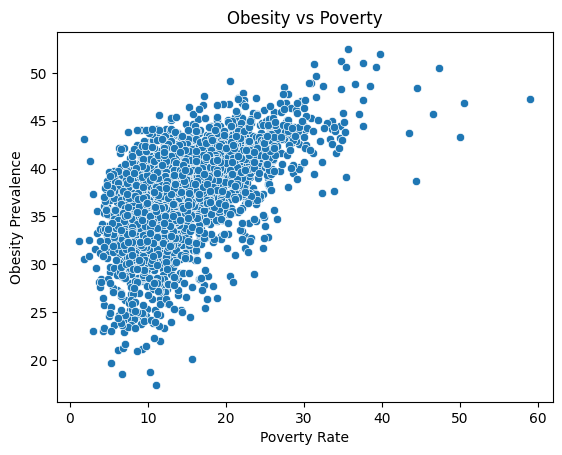

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=df["pct_ses_pov"], y=df["brfss_obesity_ageadjprv"])
plt.xlabel("Poverty Rate")
plt.ylabel("Obesity Prevalence")
plt.title("Obesity vs Poverty")
plt.show()

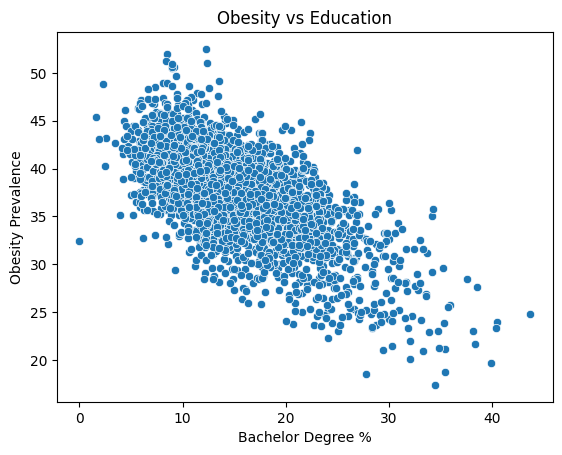

In [ ]:
sns.scatterplot(x=df["pct_ed_b"], y=df["brfss_obesity_ageadjprv"])
plt.xlabel("Bachelor Degree %")
plt.ylabel("Obesity Prevalence")
plt.title("Obesity vs Education")
plt.show()

higher poverty → higher obesity prevalence
Correlation confirms it: pct_ses_pov = 0.54

higher bachelor degree share → lower obesity
pct_ed_b = -0.66
pct_ed_gr = -0.59



smoking = 0.69
diabetes = 0.68
poor general health = 0.66

But these are health outcomes we will use structural predicators and not health coutcomes

pct_ed_b

pct_ed_gr

pct_ses_pov

pct_race_black

pct_race_white

pct_race_asian

pct_hlth_unins

pct_occ_mgt

pct_occ_prod

pct_dg_bb_int

ruca_metro

These represent:
education
poverty
race
healthcare access
occupation
internet access
urban/rural

In [ ]:
features = [
    "pct_ed_b",
    "pct_ed_gr",
    "pct_ses_pov",
    "pct_race_black",
    "pct_race_white",
    "pct_race_asian",
    "pct_hlth_unins",
    "pct_occ_mgt",
    "pct_occ_prod",
    "pct_dg_bb_int",
    "ruca_metro"
]

X = df[features]
y = df["brfss_obesity_ageadjprv"]

X.head()

,pct_ed_b,pct_ed_gr,pct_ses_pov,pct_race_black,pct_race_white,pct_race_asian,pct_hlth_unins,pct_occ_mgt,pct_occ_prod,pct_dg_bb_int,ruca_metro
0,10.6,5.4,13.4,2.1,14.6,20.9,40.0,23.9,38.6,57.5,0
1,14.4,2.4,8.3,3.5,24.5,45.8,19.6,16.1,34.1,77.0,0
2,22.8,14.0,9.1,5.4,60.3,9.7,10.5,41.6,11.1,92.7,1
3,7.3,5.5,28.5,0.9,9.6,1.4,15.1,34.4,13.3,74.8,0
4,16.8,5.3,3.5,0.6,44.8,4.1,17.0,37.2,15.8,76.5,0


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

print("R²:", model.score(X, y))

R²: 0.5981628297914565


~60% of the variation in county obesity rates
can be explained by socioeconomic and demographic variables.

analyzed 3,076 counties using merged ACS and BRFSS data.
Initial exploratory analysis shows obesity prevalence averages about 37% across counties.
Socioeconomic factors such as poverty and education show strong relationships with obesity.
A preliminary regression using structural predictors explains about 60% of the variation in county obesity rates.